# Canobie Airborne Gravity Gradiometry QC# Testing AirGravQC - Example Data

Mark Dransfield Oct 2024

## Introductory Notes to the Reader

> This notebook provides examples of the use of almost all AirGravQC functions one might use in QC. These functions cover data from airborne gravimetry surveys and gradiometry ("Falcon" and "AirFTG" types) surveys. In practice one would not have all of these different types of data in one QC notebook and it is only done here so that you can see almost all AirGravQC in one place.

> Throughout this notebook, text indented like this paragraph indicates tutorial commentary intended to explain the purpose, or highlight some feature of, the code and text of the nearby cells. The commentary is an addition to the notebook and is intended to provide extra information to someone planning to use `AirGravQC`.

> The commentary does not document the software but the usual `CMD-I` click on any function will provide the doc-string help. More information can be found in the `AirGravQC` documentation.

>> This notebook uses airborne gravity survey data to showcase the AirGravQC Python package. The data have been carefully selected from several different surveys for this purpose. Thank Sander Geophysics, Xcalibur MultiPhysics and Bell Geospace for their kindness in allowing the use of the data.
>>
>> Demonstrating the capabilities of `AirGravQC` requires data with errors for the package to find and report. Sometimes a  few survey lines have been selected from real field data that contained errors. In some cases, it proved easier to simply tighten the specifications in the code to force some data to fail.
>>
>> The datasets have been selected so that they would be small enough for distribution. The proportion of errors found by `AirGravQC` in this notebook are not in any way representative of the true situation. The actual data for all the surveys was very good.

> The introduction usually contains a summary of the data and results of QC. It should look like a management summary and should be written according to the needs of the project.

> This particular notebook is actually using data from a variety of projects so the following introduction is not accurate but it does exemplify the idea ...

## Introduction

This notebook summarises the QC of the field data delivered by Xcalibur Multiphysics on 1 Apr 2021 for the Geoscience Australia (GA) Airborne Gravity Gradiometry (AGG) Survey flown in the Queensland (Canobie Block).

The Canobie Block is Xcalibur Multiphysics project number 001 and GA project number GA5000.

The notebook is organised in line with the Technical Specifications for the survey.

A total of 2,360.5 km of data (out of a planned 4,421.3 km) were delivered from 4 flights and 37 lines.

~**All data passed review and were accepted with no re-flights.**~

Five lines were marked for re-flights. The re-flights have a minimum length of 11.2 km each, totalling 56 km. Accordingly 2304.5 km are accepted.

The first section of this notebook imports the data into the QC system and summarises the contents. The QC checks of the data are organised into following sections: Reports and Data Formats, Navigation and Positioning, Gravity, and Grids.

> The idea is that every QC check required by the contract and performed by the QC person will be in this notebook. Many checks are performed by running code from `AirGravQC` and the call to the code, and the output, are contained herein. Some other checks (for example, that a Daily Report was delivered each day) are not amenable to a check by software but they should still be reported, with the outcome of the check, within the notebook. There are also a few additional checks I like to perform. Some fall naturally under the umbrella of "best practice" and some are based on my experience. The reader should not feel obliged to use these checks themselves but they might find them useful.

> Colour coding the results makes it easy to find the areas that require more work.

### QC Colour Coding

Summary cells are coloured to quickly indicated status against QC. The colours are:

<div class="alert alert-block alert-success">
Delivery passed QC.
<div>

<div class="alert alert-block alert-info">
Delivery was not checked, or the check is not applicable, or there is a minor shortcoming but the data are acceptable.
<div>

<div class="alert alert-block alert-warning">
Delivery failed QC and problem has been reported for rectification.
<div>

<div class="alert alert-block alert-danger">
Delivery failed QC and problem might not be readily rectified. This is very rare.
<div>

## Import and Summarise

### Import required modules, and set filenames for data and plan.

> The matplotlib widget allows one to zoom in on plots made by AirGravQC (and other things like saving them to file).
>
> The pathlib package makes the naming of files a little easier in the notebook.
>
> Then import AirGravQC.

In [1]:
%matplotlib widget
from pathlib import Path

# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)
import AirGravQC as qc

> Set the paths for the data. Usually the data would be from only one project but here we are including a variety of exemplars.

> Modify to suit your data.

In [3]:
data_root = r'./CanobieData/'

canobieXYZ_file = Path(data_root + r'Canobie.xyz')
canobieHDF_file = canobieXYZ_file.with_suffix('.hdf5')

# Sometimes, but not this time, the plan data is in a different directory ...
plan_root = data_root

canobieXYZ_plan = Path(plan_root + r'CanobiePlan.xyz')
canobieHDF_plan = canobieXYZ_plan.with_suffix('.hdf5')

### Canobie Plan Data

#### Convert plan XYZ data to geoWhizz, and set metadata

In this example, the plan data file only has the (x,y) locations of the start and end of each line and we have no planned heights. The process is the same as for the acquired survey data `XYZ` file above.

In [4]:
qc.xyzToHDF(Path(canobieXYZ_plan), projectName='Canobie')
block_name = 'Survey Plan'
qc.updateProject(canobieHDF_plan, acquirer='Xcalibur Multiphysics', blockID=block_name)

Accessing XYZ data in CanobieData/CanobiePlan.xyz.
First few records are:
   /EASTING  NORTHING  FLAG

   LINE      1


  Found 1 header records
  Found 78 lines
  Found 3 fields

Creating:  CanobieData/CanobiePlan.hdf5
Setting BlockID = Survey Plan for CanobiePlan.hdf5.
Setting Acquirer = Xcalibur Multiphysics for CanobiePlan.hdf5.


In [5]:
qc.updateCoordFrame(canobieHDF_plan, x='EASTING', y='NORTHING')
qc.updateCoordFrame(canobieHDF_plan, geoDatum='WGS84', projection='UTM', utmz='54')
qc.updateLineAttributes(canobieHDF_plan, line_type='Xcal_can')

Changed CoordFrame attribute(s) for CanobiePlan.hdf5.
Changed CoordFrame attribute(s) for CanobiePlan.hdf5.
NO ACTION TAKEN ON LINE_TYPE - no plan file provided.


In [6]:
qc.updateChannelAttributes(canobieHDF_plan, 'EASTING', units='m')
qc.updateChannelAttributes(canobieHDF_plan, 'NORTHING', units='m')

Changed channel attribute(s) for EASTING in CanobiePlan.hdf5.
Changed channel attribute(s) for NORTHING in CanobiePlan.hdf5.


#### Summary report of plan data

In [7]:
qc.reportWhizz(canobieHDF_plan, )

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Survey Plan
    ProjectName: Canobie

Coordinates
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
78 lines: total distance flown [km] = 4,985.7

78 lines:
 ['1.000', '100010.000', '100020.000', '100030.000', '100040.000', '100050.000', '100060.000', '100070.000', '100080.000', '100090.000', '100100.000', '100110.000', '100120.000', '100130.000', '100140.000', '100150.000', '100160.000', '100170.000', '100180.000', '100190.000', '100200.000', '100210.000', '100220.000', '100230.000', '100240.000', '100250.000', '100260.000', '100270.000', '100280.000', '100290.000', '100300.000', '100310.000', '100320.000', '100330.000', '100340.000', '100350.000', '100360.000', '100370.000', '100380.000', '100390.000', '100400.000', '100410.000', '100420.000', '100430.000', '100440.000', '100450.000', '100460.000', '100470.000', '100480.000', '100490.000', '100500.000', '100510.000', 

### Canobie Project Measured Data

#### Convert measured XYZ data to geoWhizz, and set metadata

> The next step is essential. We need the data in HDF5 geoWhizz format because all the QC functions expect that format. (More on the geoWhizz format in the `AirGravQC` documentation.)

> Geosoft XYZ files generally have only the channel names, and no other metadata. We need the attributes of the data at project level, at line number level, and at data channel level.

In [8]:
qc.xyzToHDF(Path(canobieXYZ_file), projectName='Canobie')

Accessing XYZ data in CanobieData/Canobie.xyz.
First few records are:
   /ANE_TC_2p67 AUV_TC_2p67    Bearing BNE_TC_2p67 BUV_TC_2p67  CLEARANCE       Date        DTM    EASTING     FIDUCIAL FLIGHT gD_Fourier_2p67 GDD_Fourier_2p67 GNE_Fourier_2p67 GUV_Fourier_2p67       HDOP     HEIGHT     JOB_ID         LATITUDE       LINE        LONGITUDE   Noise_NE   Noise_UV   NORTHING NumSats       PDOP       T_DD       T_NE       T_UV  Time_1980   Time_Day TURBULENCE       VDOP

   Line  100010


  Found 1 header records
  Found 6 lines
  Found 33 fields

Creating:  CanobieData/Canobie.hdf5


PosixPath('CanobieData/Canobie.hdf5')

> Now we demonstrate the use of `updateProject()` to add additional project attributes.

> It also shows the use of `updateCoordFrame()` which keeps track of the coordinate definition and the names of the channels that contain position and time. Many QC routines use position and time, so it saves effort later to have this information in the geoWhizz group attributes.

> Field data are commonly delivered to WGS84, projected to UTM, because that is what GNSS delivers. Transformation to the desired datum happens at the end of the project for the final data.

In [9]:
block_name = 'Prelim Canobie Data'
qc.updateProject(canobieHDF_file, acquirer='Xcalibur Multiphysics', blockID=block_name)
qc.updateCoordFrame(canobieHDF_file, lat='LATITUDE', lon='LONGITUDE', x='EASTING', y='NORTHING', time='Time_1980', alt='HEIGHT')
qc.updateCoordFrame(canobieHDF_file, geoDatum='WGS84', htDatum='WGS84', projection='UTM', utmz='54')

Setting BlockID = Prelim Canobie Data for Canobie.hdf5.
Setting Acquirer = Xcalibur Multiphysics for Canobie.hdf5.
Changed CoordFrame attribute(s) for Canobie.hdf5.
Changed CoordFrame attribute(s) for Canobie.hdf5.


> The line attributes represent a challenge. Line numbers are usually coded to contain a number of impoprtant attributes: whether the line is a traverse, control, repeat or test line; which segment of a number of segments needed to complete the line, and whether it is a re-flight; and what is the line number of the corresponding planned line number. Each supplier uses a different coding system, and sometimes they will use different codings for different projects (or, worst of all (but vary rare), between staff processing the data on the same project!).

> AirGravQC knows only 3 of these systems so far and this will need expanding. So beware!

In [10]:
qc.updateLineAttributes(canobieHDF_file, planfile=canobieHDF_plan,
                        line_type='Xcal_can', flight_chan='FLIGHT', date_chan='Date')

Setting Line attributes for CanobieData/Canobie.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for CanobieData/Canobie.hdf5 to include date values from Date.

Setting Line attributes for Canobie.hdf5 according to the Xcal_can scheme.
Verifying planned line numbers against CanobieData/CanobiePlan.hdf5.


> The acquirers of the data supplied a separate text file `Channel Descriptions.txt` with the requisite channel attributes metadata which then had to be entered manually via this series of commands to store it in the geoWhizz file created by `xyzToHDF()`. There is some drudgery involved here which you will have to do for your project.

> I did not enter in the supplied descriptions for the channel attributes so all that is happening here is storing the units for each channel. Units are used in some QC checking. *Could we automate this process by reading channel description files?*

In [11]:
qc.updateChannelAttributes(canobieHDF_file, 'ANE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'AUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Bearing', units='degrees')
qc.updateChannelAttributes(canobieHDF_file, 'BNE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'BUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'CLEARANCE', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'Date')
qc.updateChannelAttributes(canobieHDF_file, 'DTM', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'EASTING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'FIDUCIAL')
qc.updateChannelAttributes(canobieHDF_file, 'FLIGHT')
qc.updateChannelAttributes(canobieHDF_file, 'gD_Fourier_2p67', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'GDD_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GNE_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GUV_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'HDOP')
qc.updateChannelAttributes(canobieHDF_file, 'HEIGHT', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'JOB_ID')
qc.updateChannelAttributes(canobieHDF_file, 'LATITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'LINE')
qc.updateChannelAttributes(canobieHDF_file, 'LONGITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_UV', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'NORTHING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'NumSats')
qc.updateChannelAttributes(canobieHDF_file, 'PDOP')
qc.updateChannelAttributes(canobieHDF_file, 'T_DD', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_UV', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'Time_1980', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'Time_Day', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'TURBULENCE', units='m/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'VDOP')

Changed channel attribute(s) for ANE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for AUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for Bearing in Canobie.hdf5.
Changed channel attribute(s) for BNE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for BUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for CLEARANCE in Canobie.hdf5.
Changed channel attribute(s) for DTM in Canobie.hdf5.
Changed channel attribute(s) for EASTING in Canobie.hdf5.
Changed channel attribute(s) for gD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GDD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GNE_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GUV_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for HEIGHT in Canobie.hdf5.
Changed channel attribute(s) for LATITUDE in Canobie.hdf5.
Changed channel attribute(s) for LONGITUDE in Canobie.hdf5.
Changed channel attribute(s) for Noise_NE in Canobie.hdf5.
Changed channel attr

#### Summary report of measured data

> Summary report of contents of data file. The `reportWhizz()` code can list attributes of a line via the `line=...` keyword, or a channel via the `channel=...` keyword.

In [12]:
qc.reportWhizz(canobieHDF_file, channel='ANE_TC_2p67')

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Coordinates
    AltitudeChannel: HEIGHT
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUDE
    Projection: UTM
    TimeChannel: Time_1980
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
6 lines: total distance flown [km] = 360.0

6 lines:
 ['100010.000', '100020.000', '100030.000', '100040.000', '100050.000', '100060.000']

33 channels:
 ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing', 'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67', 'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE', 'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP', 'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67']

Channel <HDF5 dataset "ANE_TC_2p67": shape (8040,), type "<f8">
    Name: ANE_TC

In [13]:
qc.reportFlights(canobieHDF_file, flightChannel='FLIGHT', detailed=True)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

2 flights including 6 lines.

Flights
    2
      L100010.000 L100020.000 
    3
      L100030.000 L100040.000 L100050.000 L100060.000 



> Sample times should be constant. Here we have one at 0.126 which ought to be checked. Sample distances vary with aircraft ground speed.

In [14]:
qc.reportSampling(canobieHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Sample time and distance statistics
  Min   = 0.125 s, 6.8 m
  Max   = 0.126 s, 7.9 m
  Mean  = 0.125 s, 7.4 m
  Stdev = 3.33e-05 s, 0.2 m


#### Map showing flown lines against plan.

> This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far.

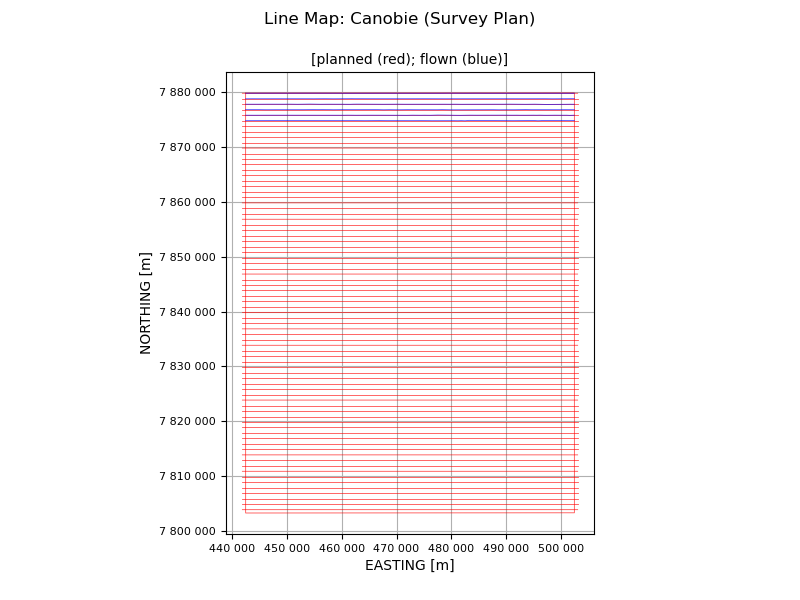

In [15]:
qc.linesMap([canobieHDF_file], whizzPlanFile=canobieHDF_plan)

## Navigation and positioning
<div class="alert alert-block alert-info">
ACCEPT
<div>

### GNSS
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum of 5 GNSS satellites visible for AGG acquisition, and PDOP, HDOP and VDOP to not exceed 4.*

All ok.

In [16]:
qc.checkGNSS(canobieHDF_file, 'NumSats', 'PDOP', 'VDOP', 'HDOP', nsats_min=5, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

In Canobie, checked num sats, PDOP, VDOP and HDOP. Found 0 errors.



> The above exemplifies my preferred reporting structure, with the contractual specification first, then any commentary or summary of QC, and finally, the actual QC check performed with its output. (`checkGNSS()` is the first instance in this notebook with all elements of the structure present.)

> Now, just to see what happens, we increase the required number of satellites to 9. The result is an error report on the one line that failed this more difficult requirement.

In [17]:
qc.checkGNSS(canobieHDF_file, 'NumSats', 'PDOP', 'VDOP', 'HDOP', nsats_min=9, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

In Canobie, checked num sats, PDOP, VDOP and HDOP. Found 1 error.
Line 100050.000 failed for 1097 fids: min sats = 8 < 9. Easting [449313, 495734], Northing [7875826, 7875850].



### Horizontal Position
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires the horizontal position to not depart from the planned position by more than 40 m for more than 1000 m.*

All ok.

In [18]:
qc.checkXYPlan(canobieHDF_plan, canobieHDF_file, allowance=40.0, maxCounter=0,
               maxDistance=1000.0, plot_flag=False)


0 exceedances known in the database.

0 lines not in plan and not checked.

0 horizontal exceedances.

0 lines with horizontal exceedances.



> Just tightened up the requirement so we can see the report from `checkXYPlan()`.


0 exceedances known in the database.

0 lines not in plan and not checked.

1 horizontal exceedances.

1 lines with horizontal exceedances.

L 100030:3 deviates more than 21.0 m for 162 fids (1237 m), max exceedance = 19 m.
  From (496548 E 7877818 N) to (497785 E 7877818 N).


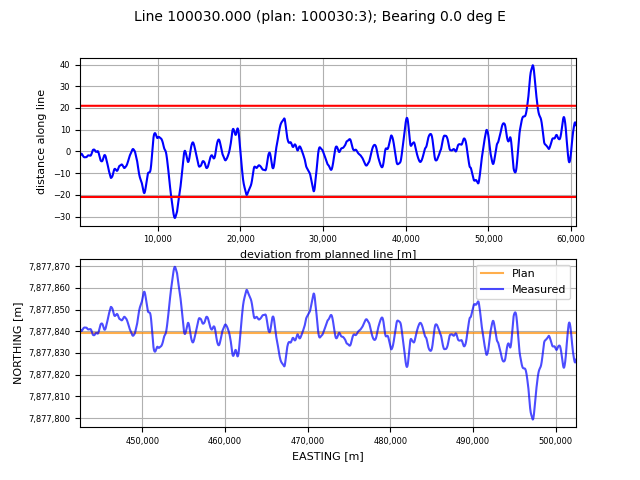

In [19]:
qc.checkXYPlan(canobieHDF_plan, canobieHDF_file, allowance=21.0, maxCounter=0,
               maxDistance=1000.0, plot_flag=True)

### Vertical Position
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires the vertical position to not depart from the planned position by more than 20 m for more than 1000 m.*

> I can't find the planned drape for Canobie, but it proceeds very like the horizontal one. Just so you can see what this QC check does, we will run it on the EastVic project data.

### Cross-over Heights
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires that the difference in height between traverse and control lines is less than some agreed maximum value.*

There are no control lines at Canobie and no specification so NA.

### Segment Lengths
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum line segment length. For Canobie, it was 11.2 km.*

OK

In [20]:
qc.checkLineLengths(canobieHDF_file, min_len=11.2)

Number failed lines = 0


### Line Overlaps
<div class="alert alert-block alert-success">
PASS
<div>

*The minimum overlap between segments of a line should be 600 m for AGG.*

> The report could be more informative here - "all overlaps met the requirement", say

In [21]:
qc.checkOverlaps(canobieHDF_file, min_overlap=0.6, plot_flag=False)

0 coincident lines found.
All overlaps meet requirement (>0.6 km).


### Ground Clearance
<div class="alert alert-block alert-success">
PASS
<div>

*This is a non-contractual check that the aircraft did not approach the ground too closely; it is a simple safety check. The settings check if the aircraft came closer than 60 m from the ground. You can change this to a number of your choice.*

All ok. Also checked at 67 m just to get a plot!

In [22]:
qc.checkSafeClearance(canobieHDF_file, 60.0, altitude_chan='HEIGHT', terrain_chan='DTM')

Number of failed lines = 0.



Number of failed lines = 2.

Clearance too low at 66 m on line 100040:3
Clearance too low at 66 m on line 100060:3


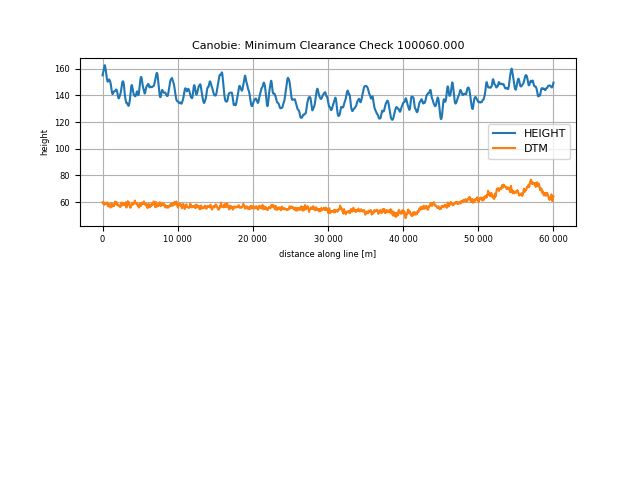

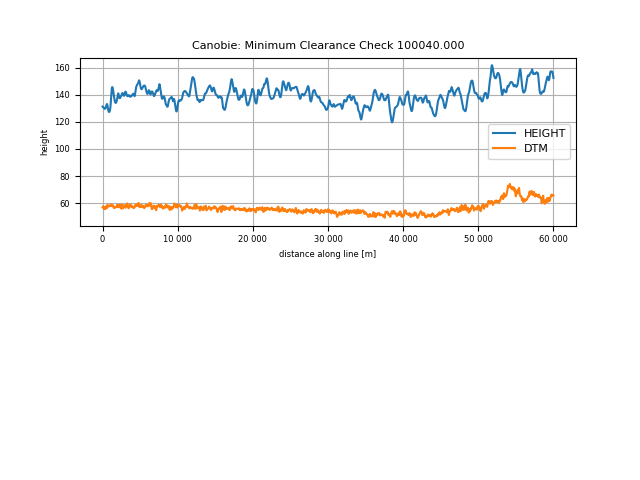

In [23]:
qc.checkSafeClearance(canobieHDF_file, 67.0, altitude_chan='HEIGHT', terrain_chan='DTM', plot_flag=True)

### Heading
<div class="alert alert-block alert-success">
PASS
<div>

  Checked 6 lines, 1 failed.

Line 100060.000: heading exceedance against tolerance 10.0. Min 259.00, Max 276.09 deg. Len=8119 fids.



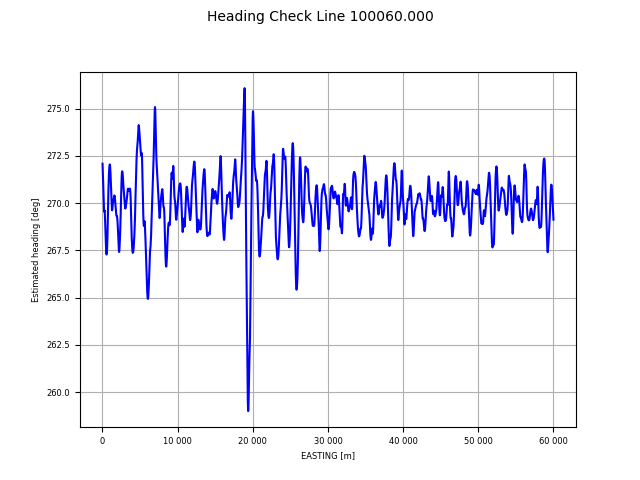

In [24]:
qc.checkHeading(canobieHDF_file, [0.0, -90, 90, 180, 360], plot_flag=True)

### Ground Speed
<div class="alert alert-block alert-success">
PASS
<div>

*The contract requires the ground speed to not exceed the range +/-15% of 60 m/s for more than 1000 m.*

All the data met the specification.

In [25]:
qc.checkSpeeds(canobieHDF_file, nominalSpeed=60., allowance=0.15, maxDistance=1000.0, plot_flag=False)

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 51.0 : 69.0 for < 1000.0 m.

 Checked 6 lines and 0 had some short exceedance(s).
 0 lines failed for exceedance > allowed.
 Total number of full exceedances = 0.

0 exceedances known in the database.




> Tightening the specification to +/- 6% induces failures so we can see how AirGravQC reports them.

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 56.4 : 63.6 for < 1000.0 m.

 Checked 6 lines and 25 had some short exceedance(s).
 2 lines failed for exceedance > allowed.
 Total number of full exceedances = 2.

0 exceedances known in the database.


L 100040:3 too slow for 24.2 sec (1353 m), peak exceedance = 55 m/s.
  From (451720 E 7876843 N) to (450367 E 7876845 N).
L 100050:3 too slow for 19.2 sec (1068 m), peak exceedance = 55 m/s.
  From (500760 E 7875851 N) to (501827 E 7875810 N).


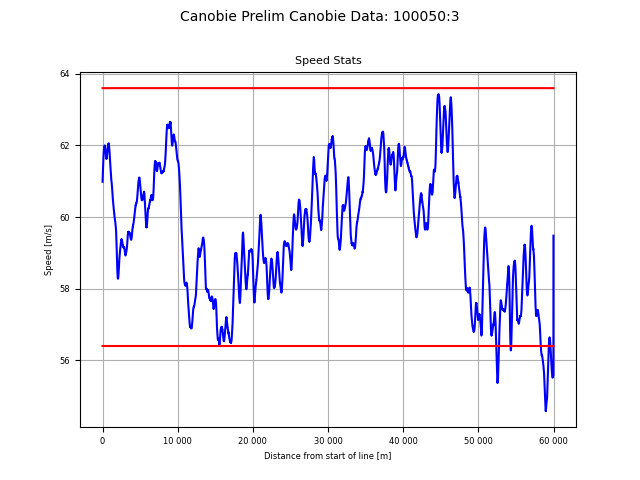

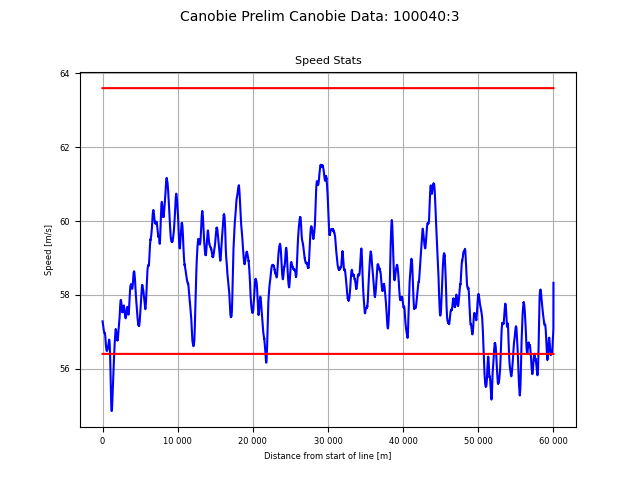

In [26]:
qc.checkSpeeds(canobieHDF_file, nominalSpeed=60., allowance=0.06, maxDistance=1000.0, plot_flag=True)

## AGG Gradiometer
<div class="alert alert-block alert-success">
PASS
<div>

### AGG Noise
<div class="alert alert-block alert-success">
PASS
<div>

*Deed requires that any line with an average noise above 5.0 E be re-flown.*

OK

> The noise depends on turbulence so it is instructive to plot each noise channel against turbulence. This also shows any outliers from the general trend (There are too few lines to see a trend here.)

> Although the specification is 5.0 E, let's set it to 2.5 E so that we get a line to fail. If we set labelLines=True, then all failed lines are labeled on the plot.

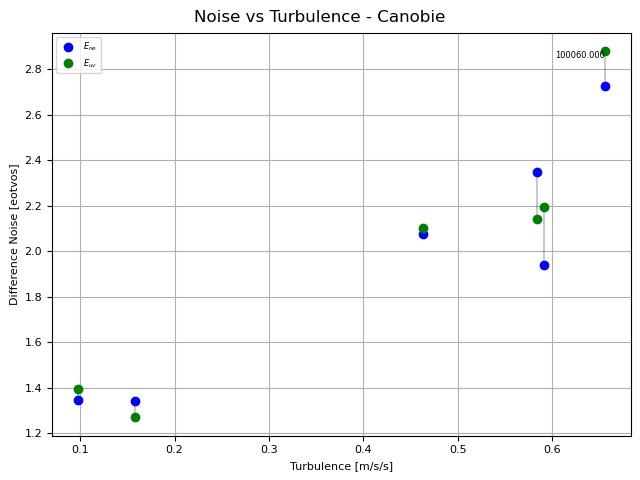

100060.000 fails with noise 2.80 > 2.5, mean turbulence = 0.66.



In [27]:
qc.diffNoiseVturb(canobieHDF_file, eNE='Noise_NE', eUV='Noise_UV', turbulence='TURBULENCE',
                  error_spec=2.5, labelLines=True)

> Any rectification process can down-convert high frequency vibration into the signal band of a sensor. Gravity gradiometers have an intrinsic rectification process via their sensitivity to products of rotational velocity so it is useful to check for excess high frequency signal since it may lead to error in the final data.

> For the AGG system, a noiseLimit of ~15 E ought to be followed up with the acquisition company. Here I set the noiseLimit much lower in order to demonstrate the plotting of the result.

> The raw gradients are high-pass filtered and a rolling standard deviation is used to find periods of higher amplitudes. Turbulence is a likely cause of excess vibration so the turbulence is also plotted for comparison.

> This is not a contractual check in the Deed.

Checked 6 lines; 1 line had high frequency signal above 6.5.
Line 100030.000: peak HF noise in ANE_TC_2p67 = 6.9.



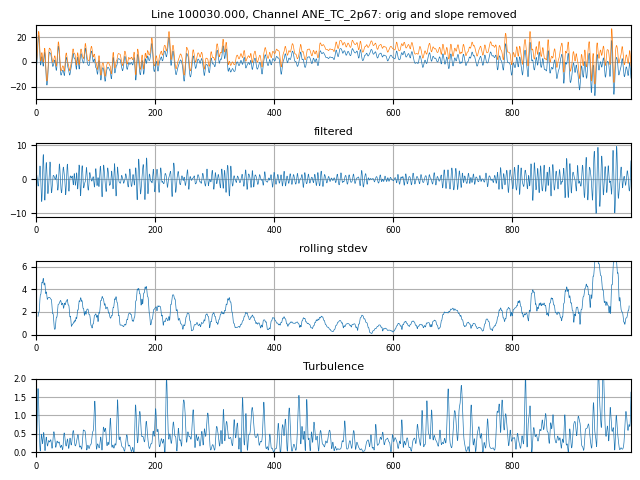

In [28]:
qc.checkHighFreq(canobieHDF_file, noiseLimit=6.5, 
                 channels=['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67'], 
                 cutoffs=[0.15, 3.6], vertaccel='TURBULENCE', verbose=True, plot_flag=True)

analysing 100010.000 of 6.
analysing 100020.000 of 6.


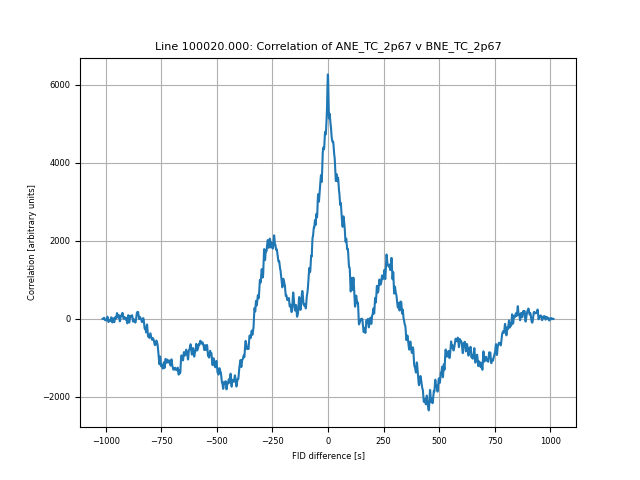

Offset MEAN = -0.67; STD = 1.491
analysing 100030.000 of 6.
analysing 100040.000 of 6.
analysing 100050.000 of 6.
analysing 100060.000 of 6.


In [29]:
qc.checkPhase(canobieHDF_file, 'ANE_TC_2p67', 'BNE_TC_2p67', tolerance=0.5, lines=[], plot_flag=True)

analysing 100010.000 of 6.
analysing 100020.000 of 6.
analysing 100030.000 of 6.
analysing 100040.000 of 6.
analysing 100050.000 of 6.
analysing 100060.000 of 6.


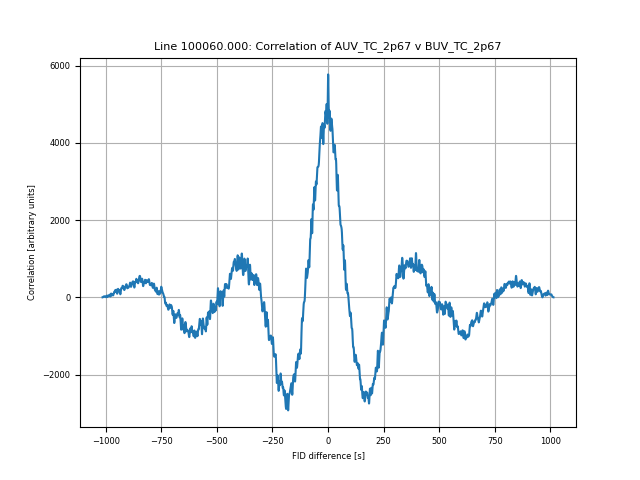

Offset MEAN = 1.17; STD = 2.192


In [30]:
qc.checkPhase(canobieHDF_file, 'AUV_TC_2p67', 'BUV_TC_2p67', tolerance=0.5, lines=[], plot_flag=True)

## Statistics and Grids
<div class="alert alert-block alert-info">
NA
<div>

### Data Quality
<div class="alert alert-block alert-success">
PASS
<div>

*None of the following checks are contractually required but they can give some insights to data quality.*

---
The only spikes found were at very small amplitudes on otherwise smooth fields (terrain corrections). All ok.

> The following channels should vary smoothly without spikes. You can choose different channels to test for your project but I have found this test to generally be too sensitive. The algorithm could be improved.

In [31]:
qc.checkSpikes(canobieHDF_file, channels=['Bearing', 'Noise_NE', 'Noise_UV', 'gD_Fourier_2p67', 'T_DD', 'T_NE', 'T_UV', \
                            'LATITUDE', 'LONGITUDE', 'EASTING', 'NORTHING', 'DTM'])

Checked 12 channels in 6 lines and no spikes found.


---
The only failures are in the `Time_Day` channel and all are within 1 second of midnight. Time of day does not vary with constant slope at midnight so this is not a concern. Of course the aircraft was not flying at midnight, suggesting the the relevant clock is in the wrong time zone but this is not a concern.

> The checked fields should each vary uniformly with constant slope.

In [32]:
qc.checkConstantSlope(canobieHDF_file, channels=['Date', 'FIDUCIAL', 'FLIGHT', 'LINE', 'Time_Day', 'JOB_ID', \
                                   'Time_1980'])


  100010.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100010.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100060.000; Time_Day Largest difference (= 0.000999) > 0.1% of

---
All channel statistics look as expected. OK.

> Just plot the mean, standard deviation and range of every channel as a for every line. A lot of information condensed here which I find useful. I just run my eye quickly over the plots looking for outliers, and I check the vertical scales to ensure that the values are in about the right range.
>
Here the CLEARANCE has an obvious outlier maximum in line 100050.

In [100]:
# Normally, plot the stats for all channels whatsoever. But to save space, we will just do a few in the next notebook cell, and comment this one out.
# qc.allChanStats(canobieHDF_file, ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing',
#                      'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67',
#                      'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE',
#                      'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP',
#                      'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67'])

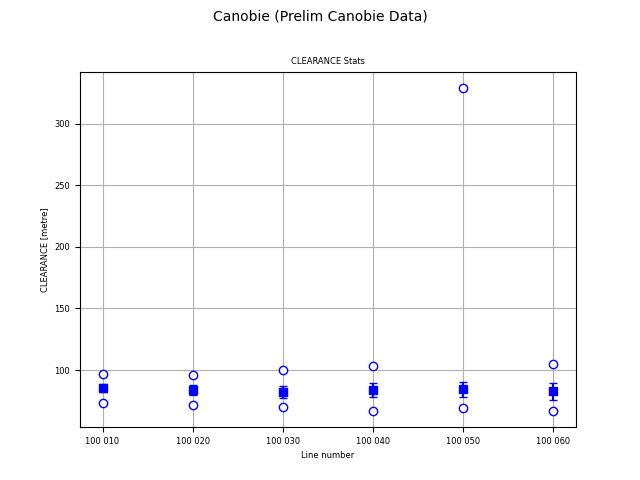

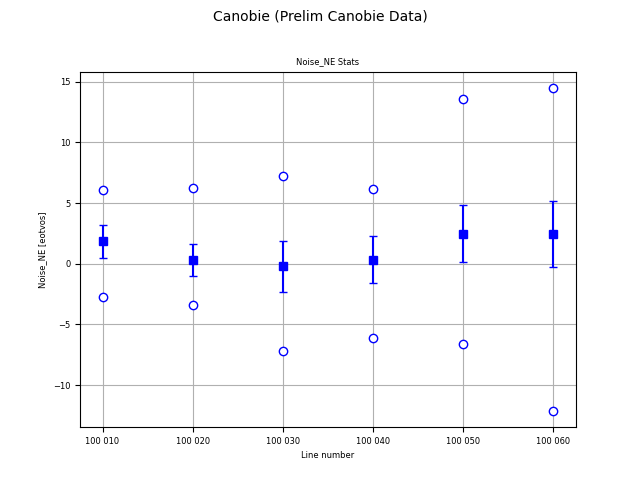

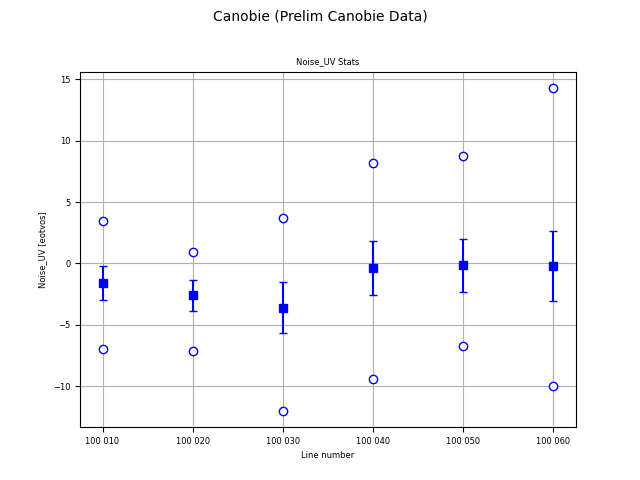

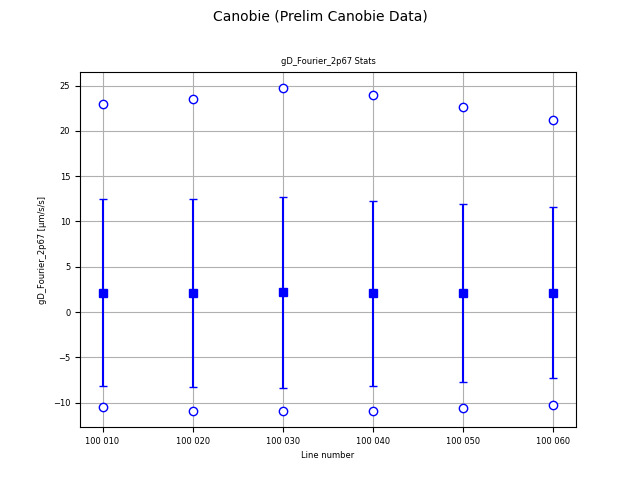

In [33]:
qc.allChanStats(canobieHDF_file, ['CLEARANCE', 'Noise_NE', 'Noise_UV', 'gD_Fourier_2p67'])

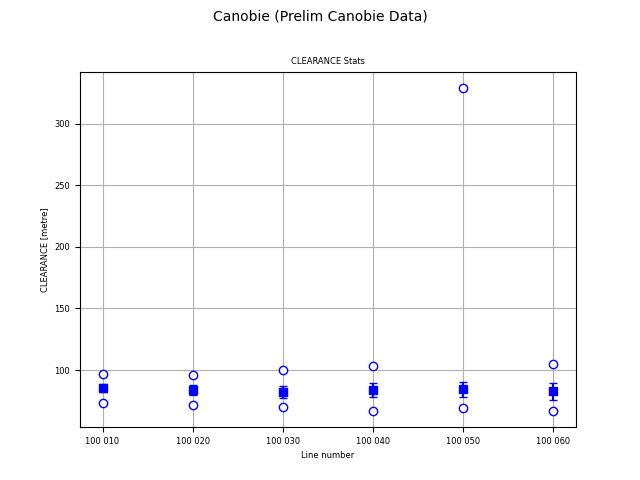

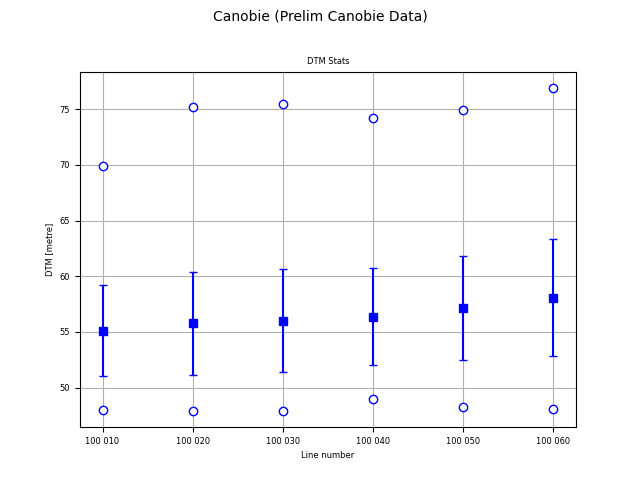

In [34]:
qc.allChanStats(canobieHDF_file, ['CLEARANCE', 'DTM'])

### Even-Odd Grids
<div class="alert alert-block alert-success">
PASS
<div>

> For the Vinton Dome data, we don't have any specification. This example just demonstrates the use of the function. Note that the user needs to specify the odd and even lines. Often the line numbering system makes this reasonably easy, but not always (and certainly not here).

### Delivered Grids
<div class="alert alert-block alert-info">
NA
<div>

*For Canobie, there was no requirement for grids of field data to be delivered and none were.*

> The Deed does not have specifications on the quality of gridded field data but grids are a quick and easy way to spot any artefacts in the data. So they are useful in checking for "best practice".

> The function `checkErsHeaders()` is useful when there are supplied grids.

> In any case, I always generate grids from the located data.

In [106]:
# qc.checkErsHeaders(ersp)

### Generated Grids
<div class="alert alert-block alert-success">
PASS
<div>

*There are no Deed specifications on the grids except "best practice".*

All the grids look okay and there are no serious artefacts.

> I grid and image almost every channel in the database (here I have only done a few as examples). Channels that are directionally dependent have the mean for each line removed ("mr") before gridding. For some channels it is more useful to examine the grid of the first difference along each line ("d1").

> It might be useful to comment on some particular images.

>> The "long-form parameter" warnings are generated by pygmt version 0.11.0. The older versions of pygmt fail if the long-form parameters are used, so for now, we are living with the warnings.


Gridding and imaging Bearing
6 lines; total number of fids in whizz file = 48583.
    Bearing (mr): min = -10.986009852216796, max = 6.113990147783227.
Processing (x, y, z) = (EASTING, NORTHING, MR_Bearing). MR_Bearing in degrees.


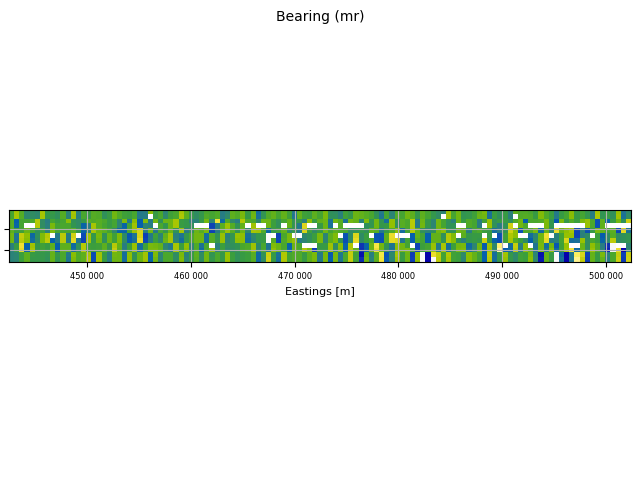

RMS of result = 1.20 degrees
Gridding and imaging FLIGHT
6 lines; total number of fids in whizz file = 48583.
    FLIGHT (d1): min = 0.0, max = 0.0.
Processing (x, y, z) = (EASTING, NORTHING, D1_FLIGHT). D1_FLIGHT in .


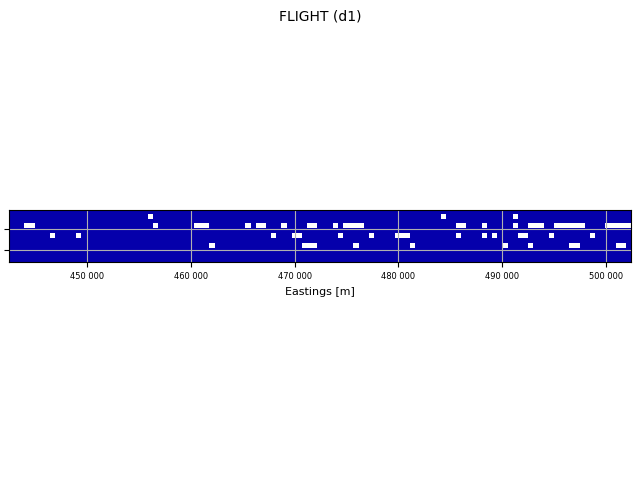

RMS of result = 0.00 
Gridding and imaging GDD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    GDD_Fourier_2p67: min = -29.47, max = 67.3.
Processing (x, y, z) = (EASTING, NORTHING, GDD_Fourier_2p67). GDD_Fourier_2p67 in eotvos.


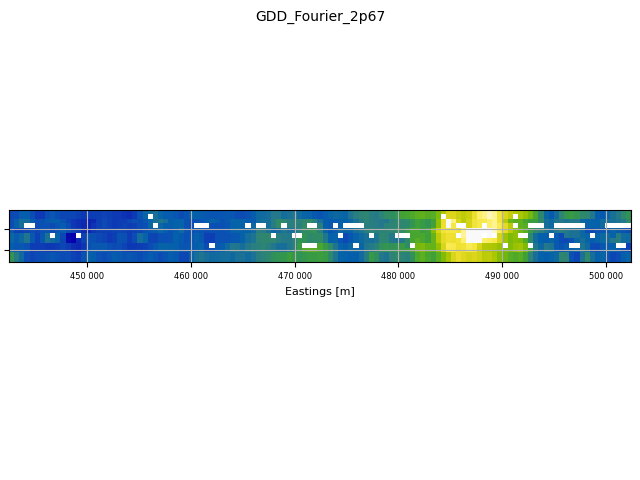

RMS of result = 17.26 eotvos
Gridding and imaging Time_1980
6 lines; total number of fids in whizz file = 48583.
    Time_1980 (d1): min = 0.125, max = 0.12600016593933105.
Processing (x, y, z) = (EASTING, NORTHING, D1_Time_1980). D1_Time_1980 in seconds.


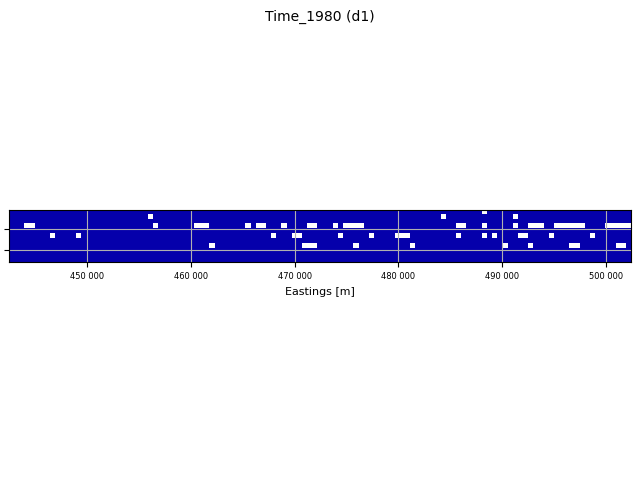

RMS of result = 0.00 seconds
Gridding and imaging gD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    gD_Fourier_2p67: min = -10.92, max = 24.71.
Processing (x, y, z) = (EASTING, NORTHING, gD_Fourier_2p67). gD_Fourier_2p67 in µm/s/s.


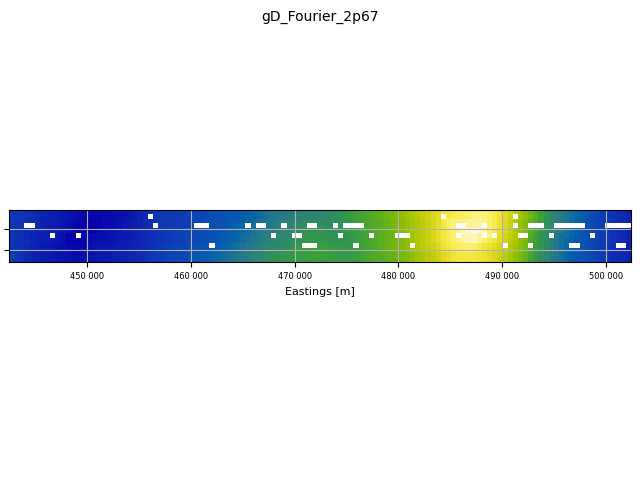

RMS of result = 10.14 µm/s/s


In [35]:
z_chans = ['Bearing', 'FLIGHT', 'GDD_Fourier_2p67', 'Time_1980', 'gD_Fourier_2p67']
mr_chans = ['Bearing']
d1_chans = ['FLIGHT', 'Time_1980']
qc.grid_n_image(canobieHDF_file, z_chans, 500.0, mr_chans=mr_chans, d1_chans=d1_chans)

**THE END**